In [13]:
from collections import Counter
import re
import pandas as pd
from pathlib import Path

interview_files = [
    "/content/Benjamin-interview.txt",
    "/content/Roy-interview.txt",
    "/content/Interview-Roland.txt",
    "/content/Interview-Selina.txt",
    "/content/interview-students.txt",
    "/content/Thomas-interview.txt"
]

# Define basic negative keywords manually to help us extract relevant sentiment phrases
negative_keywords = [
    "not", "hard", "difficult", "problem", "issue", "wrong", "slow", "bad", "confusing",
    "mistake", "inaccurate", "irrelevant", "repetitive", "unclear", "random", "limitation",
    "need improvement", "drawback", "fall short", "off-topic", "missing", "long", "time-consuming"
]

# Helper function to extract relevant sentences with negative keywords
def extract_negative_keywords(filepath):
    with open(filepath, 'r', encoding='utf-8') as file:
        text = file.read().lower()

    sentences = re.split(r'(?<=[.!?])\s+', text)
    relevant_phrases = []

    for sentence in sentences:
        for keyword in negative_keywords:
            if keyword in sentence:
                relevant_phrases.append(sentence.strip())
                break  # Avoid duplicating a sentence for multiple keywords

    return relevant_phrases


all_phrases = []
for file in interview_files:
    phrases = extract_negative_keywords(Path("/content") / file)
    all_phrases.extend(phrases)

# Tokenize and count keyword frequencies
tokenized_words = [word for phrase in all_phrases for word in re.findall(r'\b\w+\b', phrase)]
keyword_counts = Counter(tokenized_words)

# Filter out common words and keep relevant negative sentiment words
common_words = set([
    "the", "and", "to", "of", "a", "in", "is", "it", "that", "for", "on", "with", "are",
    "as", "this", "i", "you", "was", "but", "have", "be", "we", "they", "not", "so", "if"
])
filtered_keywords = {word: count for word, count in keyword_counts.items() if word not in common_words and word in set(negative_keywords)}

# Convert to DataFrame for display
df_keywords = pd.DataFrame(filtered_keywords.items(), columns=["Keyword", "Frequency"]).sort_values(by="Frequency", ascending=False)

# df = pd.DataFrame(filtered_keywords.items(), columns=["Keyword", "Frequency"])
df.sort_values(by="Frequency", ascending=False).head(20)


,Keyword,Frequency
8,hard,35
2,random,25
3,wrong,22
0,long,21
4,difficult,20
1,problem,19
11,confusing,7
5,bad,4
10,missing,4
6,mistake,4


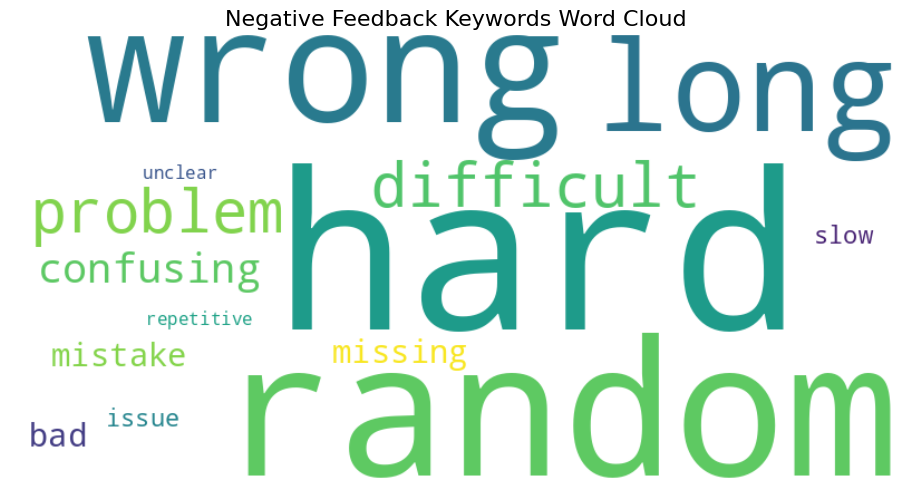

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate a word cloud from the filtered keywords
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(filtered_keywords)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Feedback Keywords Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
from collections import Counter
import re
import pandas as pd
from pathlib import Path
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Reload interview file paths
interview_files = [
    "/content/Benjamin-interview.txt",
    "/content/Roy-interview.txt",
    "/content/Interview-Roland.txt",
    "/content/Interview-Selina.txt",
    "/content/interview-students.txt",
    "/content/Thomas-interview.txt"
]

# Define positive keywords
positive_keywords = [
    "useful", "helpful", "good", "great", "creative", "efficient", "save time",
    "easy", "inspiring", "high quality", "relevant", "fast", "clear", "intuitive", "valuable"
]

# Extract positive sentiment phrases
def extract_positive_keywords(filepath):
    with open(filepath, 'r', encoding='utf-8') as file:
        text = file.read().lower()
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if any(k in s for k in positive_keywords)]

# Collect all positive phrases
all_positive_phrases = []
for file in interview_files:
    all_positive_phrases.extend(extract_positive_keywords(file))

# Tokenize and count keywords
tokenized = [word for phrase in all_positive_phrases for word in re.findall(r'\b\w+\b', phrase)]
positive_counts = Counter(tokenized)

# Filter relevant keywords only
filtered_positive_keywords = {
    word: count for word, count in positive_counts.items()
    if word in set([kw.split()[0] for kw in positive_keywords])
}

# Prepare DataFrame
df_positive = pd.DataFrame(filtered_positive_keywords.items(), columns=["Keyword", "Frequency"]).sort_values(by="Frequency", ascending=False)
# df = pd.DataFrame(filtered_keywords.items(), columns=["Keyword", "Frequency"])
df.sort_values(by="Frequency", ascending=False).head(20)


,Keyword,Frequency
8,hard,35
2,random,25
3,wrong,22
0,long,21
4,difficult,20
1,problem,19
11,confusing,7
5,bad,4
10,missing,4
6,mistake,4


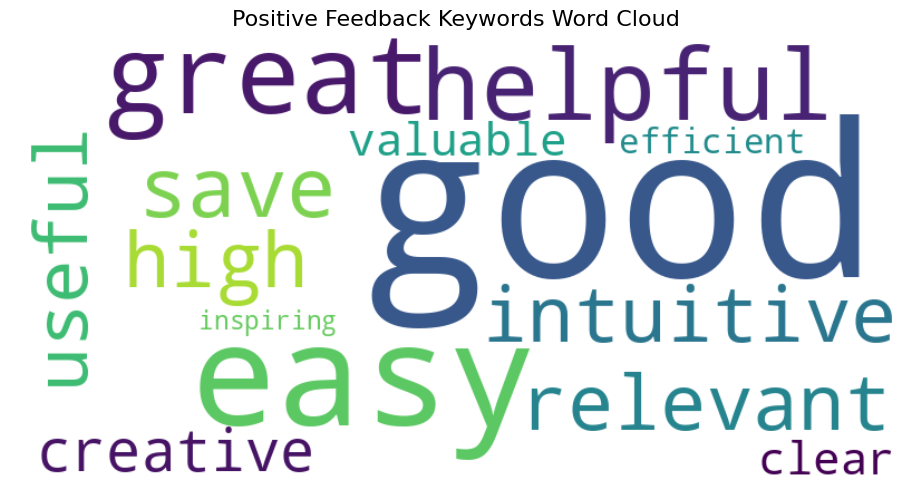

In [11]:
# Generate a word cloud from the filtered positive keywords
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(filtered_positive_keywords)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Feedback Keywords Word Cloud", fontsize=16)
plt.tight_layout()
plt.show()


In [4]:
pip install wordcloud matplotlib
